# Week 2 — Collaborative Filtering

This notebook covers:
- **Task 2.1** — Temporal train/test split
- **Task 2.2** — Memory-based CF (user-based & item-based)
- **Task 2.3** — Model-based CF: SVD (Surprise) and NMF (Scikit-learn)
- **Task 2.4** — Precision@K and Recall@K evaluation

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../src')

ratings = pd.read_csv('../data/processed/ratings_clean.csv', parse_dates=['rating_date'])
movies  = pd.read_csv('../data/processed/movies_content.csv')

print(f"Ratings loaded : {len(ratings):,}")
print(f"Users          : {ratings['userId'].nunique()}")
print(f"Movies         : {ratings['movieId'].nunique()}")
print(ratings.dtypes)

Ratings loaded : 90,274
Users          : 610
Movies         : 3650
userId                  int64
movieId                 int64
rating                float64
timestamp               int64
rating_date    datetime64[us]
user_idx                int64
item_idx                int64
dtype: object


## Task 2.1 — Temporal Train/Test Split

For each user we hold out their **most recent** rating as the test item. All earlier ratings form the training set.

**Why temporal?** Random splits leak future information into training. In a real system you only know what happened before a given moment — a temporal split simulates that correctly.

In [2]:
# Sort by user then time so the last row per user is the most recent rating
ratings_sorted = ratings.sort_values(['userId', 'rating_date'])

# Hold out each user's single most recent rating as the test set
test  = ratings_sorted.groupby('userId').tail(1).copy()
train = ratings_sorted.drop(test.index).copy()

print(f"Train : {len(train):,} ratings")
print(f"Test  : {len(test):,} ratings  (1 per user)")
print(f"\nTrain date range: {train['rating_date'].min().date()} → {train['rating_date'].max().date()}")
print(f"Test  date range: {test['rating_date'].min().date()} → {test['rating_date'].max().date()}")

Train : 89,664 ratings
Test  : 610 ratings  (1 per user)

Train date range: 1996-03-29 → 2018-09-24
Test  date range: 1996-03-29 → 2018-09-24


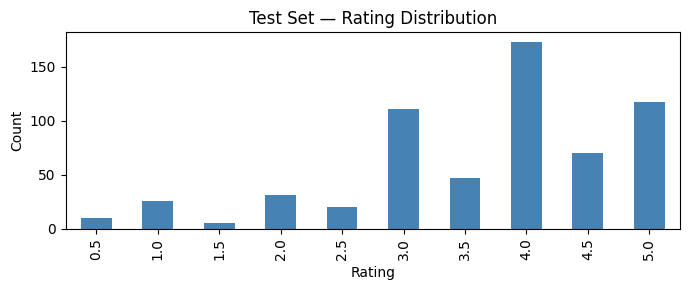


Test rating stats:
count    610.00
mean       3.67
std        1.11
min        0.50
25%        3.00
50%        4.00
75%        4.50
max        5.00
Name: rating, dtype: float64


In [3]:
# Sanity check — every user appears exactly once in test
assert test['userId'].nunique() == ratings['userId'].nunique(), "Some users missing from test split"
assert test.groupby('userId').size().max() == 1, "Some users have >1 test rating"

# Distribution of test ratings
fig, ax = plt.subplots(figsize=(7, 3))
test['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Test Set — Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/viz_test_split.png', dpi=120)
plt.show()

print("\nTest rating stats:")
print(test['rating'].describe().round(2))